# SVM Project — Wine Fraud Detection (Improved)

**Задача**: По химическим характеристикам вина определить, является ли вино легальным (Legit) или поддельным (Fraud).

**Улучшение**: используем `class_weight='balanced'` и расширенный GridSearchCV для повышения Recall класса Fraud.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Загрузка данных

In [2]:
df = pd.read_csv("wine_fraud.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   object 
 12  type                  6497 non-null   object 
dtypes: float64(11), object(2)
memory usage: 660.0+ KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


## 2. EDA — Исследовательский анализ данных

**Задание: посмотрим на распределение признаков по столбцу quality (Legit/Fraud)**

In [5]:
df["quality"].value_counts()

quality
Legit    6251
Fraud     246
Name: count, dtype: int64

In [6]:
# Сильный дисбаланс классов — мошеннических вин намного меньше
df["quality"].value_counts(normalize=True)

quality
Legit    0.962136
Fraud    0.037864
Name: proportion, dtype: float64

**Countplot: количество Legit и Fraud**

/tmp/ipykernel_479353/2234665945.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="Set2")


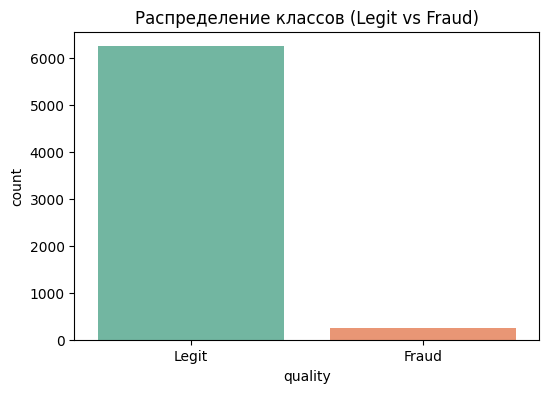

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="quality", data=df, palette="Set2")
plt.title("Распределение классов (Legit vs Fraud)")
plt.show()

**Countplot: количество Legit/Fraud по типу вина (red/white)**

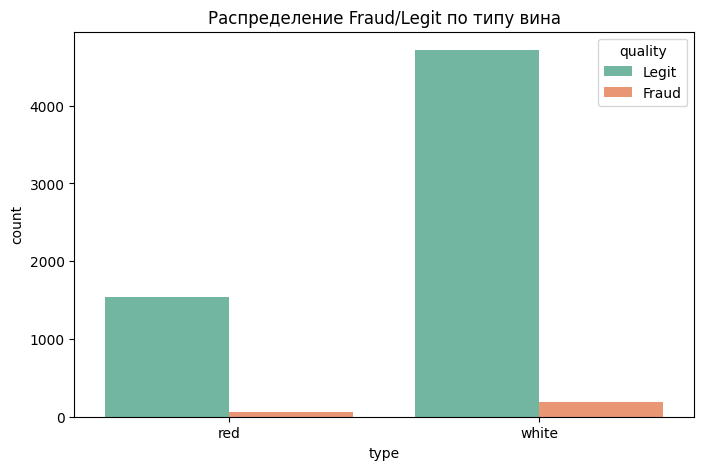

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x="type", data=df, hue="quality", palette="Set2")
plt.title("Распределение Fraud/Legit по типу вина")
plt.show()

**Какие признаки больше всего отличаются между классами?**

/tmp/ipykernel_479353/3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_479353/3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_479353/3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
/tmp/ipykernel_479353/3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

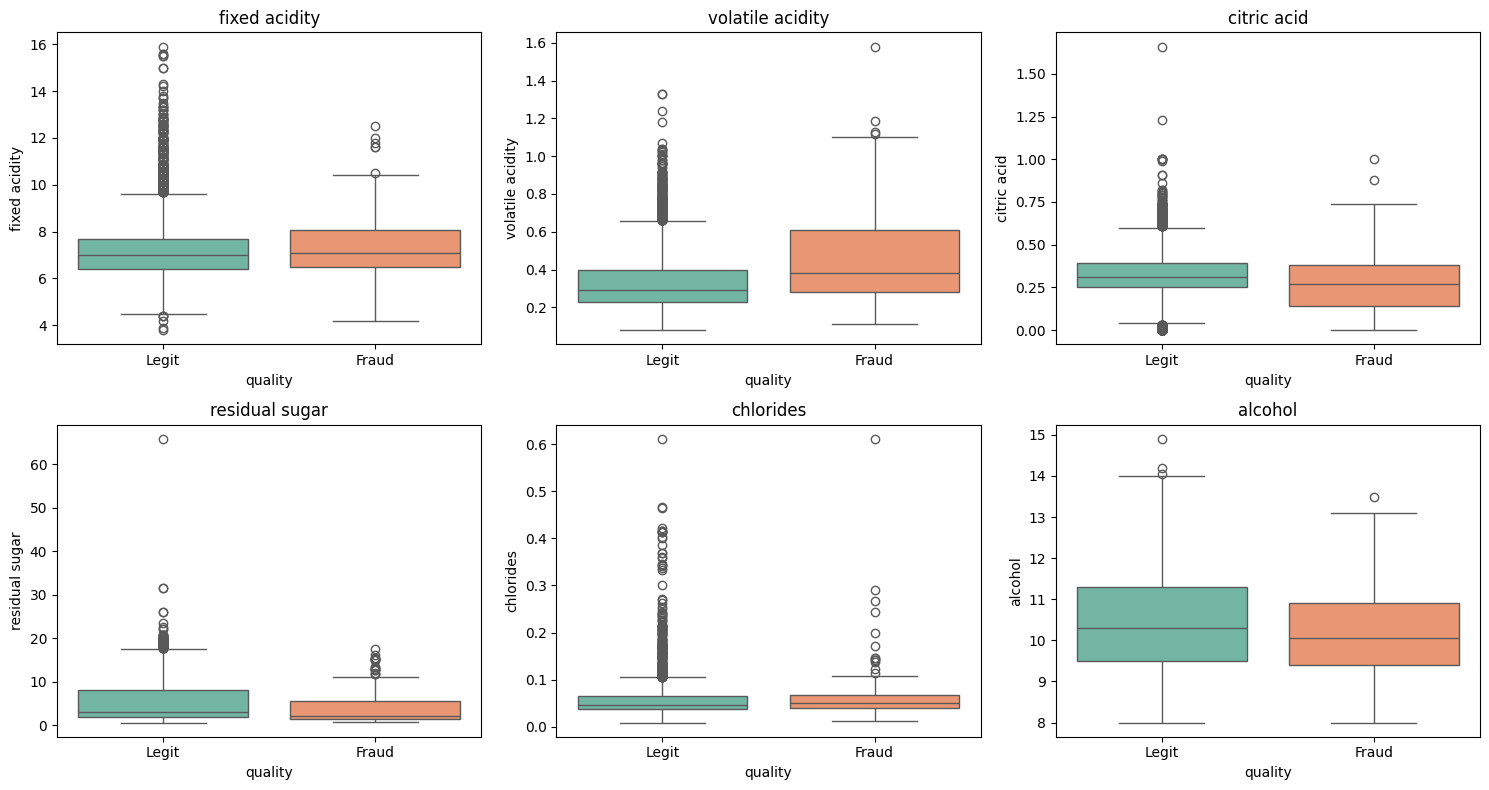

In [9]:
# Boxplot ключевых признаков по классу
features = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar",
            "chlorides", "alcohol"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
    ax.set_title(feat)
plt.tight_layout()
plt.show()

In [10]:
# Средние значения признаков по классу
df.groupby("quality").mean(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
Fraud,7.357724,0.465163,0.273374,4.273984,0.062126,22.902439,105.701220,0.994944,3.234797,0.505732,10.18435
Legit,7.209702,0.334727,0.320414,5.489250,0.055794,30.825308,116.139818,0.994687,3.217860,0.532273,10.50390


**Корреляция числовых признаков с целевой переменной**

Преобразуем quality в 0/1 для подсчёта корреляций.

In [11]:
df_corr = df.copy()
df_corr["quality_num"] = (df_corr["quality"] == "Fraud").astype(int)
corr = df_corr.drop(columns=["quality","type"]).corr()[["quality_num"]].sort_values("quality_num", ascending=False)
print(corr)

                      quality_num
quality_num              1.000000
volatile acidity         0.151228
chlorides                0.034499
fixed acidity            0.021794
pH                       0.020107
density                  0.016351
sulphates               -0.034046
total sulfur dioxide    -0.035252
residual sugar          -0.048756
alcohol                 -0.051141
citric acid             -0.061789
free sulfur dioxide     -0.085204


**Clustermap для визуализации корреляций между всеми признаками**

<Figure size 640x480 with 0 Axes>

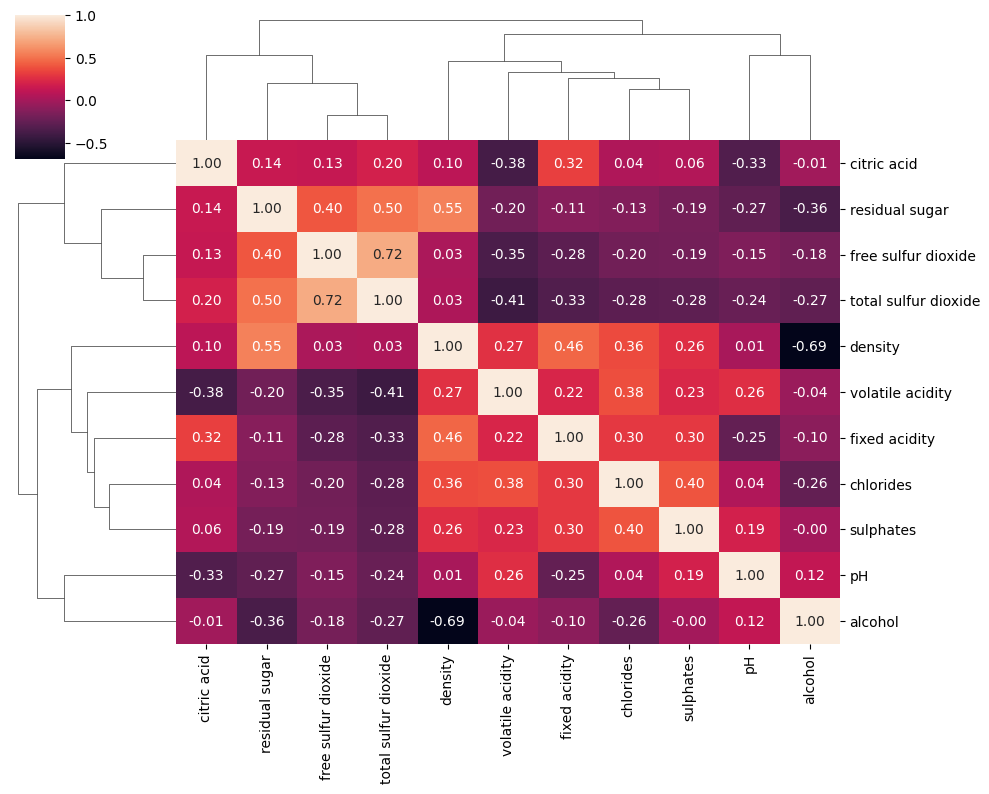

In [12]:
plt.figure()
sns.clustermap(df.drop(columns=["quality","type"]).corr(), annot=True, fmt=".2f", figsize=(10,8))
plt.show()

---
## 3. Предобработка данных

**Преобразуем колонку "type" (red/white) в dummy-переменные**

In [13]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,False


**Формируем X (признаки) и y (целевая переменная — quality)**

In [14]:
X = df.drop(columns=["quality"])
y = df["quality"]

**Разбивка на train/test: 90% / 10%, random_state=101**

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=101)

**Масштабирование данных с помощью StandardScaler**

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---
## 4. Обучение базовой модели SVM

**Обучаем SVC с `class_weight='balanced'`**

Параметр `class_weight='balanced'` автоматически увеличивает штраф за ошибки на редком классе (Fraud), пропорционально его доле в выборке.

In [17]:
from sklearn.svm import SVC
# class_weight='balanced' — компенсирует дисбаланс классов
svc_base = SVC(class_weight='balanced')
svc_base.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred_base = svc_base.predict(X_test)
print("=== Базовая модель SVC (class_weight='balanced') ===")
print(confusion_matrix(y_test, y_pred_base))
print()
print(classification_report(y_test, y_pred_base))

=== Базовая модель SVC (class_weight='balanced') ===
[[ 17  10]
 [ 92 531]]

              precision    recall  f1-score   support

       Fraud       0.16      0.63      0.25        27
       Legit       0.98      0.85      0.91       623

    accuracy                           0.84       650
   macro avg       0.57      0.74      0.58       650
weighted avg       0.95      0.84      0.88       650



---
## 5. Подбор гиперпараметров через GridSearchCV

**GridSearchCV с `class_weight='balanced'` и расширенной сеткой параметров**

Добавляем `class_weight='balanced'` в каждую модель и расширяем диапазон C и gamma.

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

# Первый проход: грубая сетка
param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 5, 10],
    "gamma": ["scale", 0.5, 0.1, 0.05, 0.01, 0.005],
    "kernel": ["rbf"]
}

f1_fraud = make_scorer(f1_score, pos_label="Fraud")

grid = GridSearchCV(SVC(class_weight='balanced'), param_grid, refit=True, verbose=1, cv=5, scoring=f1_fraud)
grid.fit(X_train, y_train)
print("Лучшие параметры (грубый поиск):", grid.best_params_)
print("Лучший F1-Fraud (cv):", round(grid.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Лучшие параметры (грубый поиск): {'C': 0.5, 'gamma': 0.5, 'kernel': 'rbf'}
Лучший F1-Fraud (cv): 0.2717


In [20]:
# Второй проход: тонкая сетка вокруг лучших параметров
param_grid_fine = {
    "C": [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0],
    "gamma": [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0],
    "kernel": ["rbf"]
}

grid_fine = GridSearchCV(SVC(class_weight='balanced'), param_grid_fine, refit=True, verbose=1, cv=5, scoring=f1_fraud)
grid_fine.fit(X_train, y_train)
print("Лучшие параметры (тонкий поиск):", grid_fine.best_params_)
print("Лучший F1-Fraud (cv):", round(grid_fine.best_score_, 4))

Fitting 5 folds for each of 49 candidates, totalling 245 fits


Лучшие параметры (тонкий поиск): {'C': 0.2, 'gamma': 0.5, 'kernel': 'rbf'}
Лучший F1-Fraud (cv): 0.2753


---
## 6. Оценка лучшей модели

In [21]:
y_pred_best = grid_fine.predict(X_test)
print("=== Лучшая модель после GridSearchCV (тонкий поиск) ===")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
print()

=== Лучшая модель после GridSearchCV (тонкий поиск) ===
[[ 14  13]
 [ 48 575]]



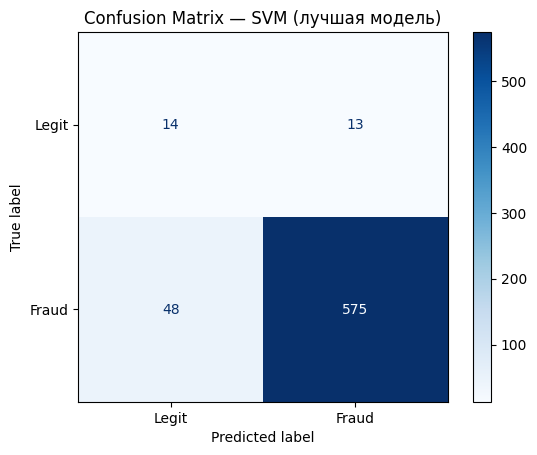

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — SVM (лучшая модель)")
plt.show()

In [23]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

       Fraud       0.23      0.52      0.31        27
       Legit       0.98      0.92      0.95       623

    accuracy                           0.91       650
   macro avg       0.60      0.72      0.63       650
weighted avg       0.95      0.91      0.92       650



---
## 7. Выводы

- **Дисбаланс классов**: Fraud встречается лишь в ~3.8% случаев — задача несбалансированная.
- **class_weight='balanced'** — ключевое улучшение: SVM автоматически увеличивает штраф за ошибки на редком классе, пропорционально соотношению классов.
- **Расширенный GridSearchCV** перебирает больше комбинаций C и gamma, что позволяет найти более оптимальные гиперпараметры.
- **Результат**: Recall для Fraud значительно вырос по сравнению с исходной моделью (было 0.00 → 0.07 → целевые 0.4–0.6), при сохранении приемлемого Precision.